In [1]:
# Базовые библиотеки для воспроизводимости, анализа и визуализации.
import random
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import torch.nn.functional as F

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

RANDOM_STATE = 42

# Переменные директорий
ROOT = Path(".")
# DATA_DIR = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts"

# DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

C:\Users\vnars\Desktop\AIE-course\pythonHW13\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Загрузка датасета ##
sanity-check по данным: размер датасета, названия классов, несколько примеров текстов и меток;

In [3]:
# Загрузка данных через datasets
# Датасет загружен через datasets для демонстрации API HuggingFace.
# Далее используется версия, загруженная через pandas для удобства работы

hf_dataset = load_dataset("mani323/emotion")

hf_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 15956
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1988
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1986
    })
})

In [4]:
# Загрузка данных через pandas

# DF_URL = "hf://datasets/boltuix/emotions-dataset/emotions_dataset.parquet"
# df = pd.read_parquet(DF_URL)
# df.head(10)

splits = {'train': 'data/train-00000-of-00001.parquet', 'validation': 'data/validation-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/mani323/emotion/" + splits["train"])

# объединение для собственной разбивки на train/val/test
df = pd.concat([
    pd.read_parquet("hf://datasets/mani323/emotion/" + splits["train"]),
    pd.read_parquet("hf://datasets/mani323/emotion/" + splits["validation"]),
    pd.read_parquet("hf://datasets/mani323/emotion/" + splits["test"]),
], ignore_index=True)

df = df[["text", "label_text"]].rename(columns={"label_text": "label"})
df.head(10)

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasnt sure why that was,sadness
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny,surprise
7,i feel as confused about life as a teenager or as jaded as a year old man,fear
8,i have been with petronas for years i feel that petronas has performed well and made a huge profit,joy
9,i feel romantic too,love


In [5]:
# sanity check
print("Пропуски:")
print(df.isna().sum())

if df.isna().sum().sum() > 0:
    df = df.dropna().reset_index(drop=True)
else:
    print("Нет пропусков")
    
label_names = sorted(df["label"].unique())

# Смотрим размер датасета и распределение по классам.
print("Размер датасета:", len(df))
print("Имена классов", label_names)

display(df["label"].value_counts())

label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

display(df.sample(6, random_state=RANDOM_STATE).reset_index(drop=True))

Пропуски:
text     0
label    0
dtype: int64
Нет пропусков
Размер датасета: 19930
Имена классов ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


label
joy         6733
sadness     5792
anger       2700
fear        2366
love        1626
surprise     713
Name: count, dtype: int64

label2id: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
id2label: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}


,text,label,label_id
0,i feel so eager to do things the way he wants and likes,joy,2
1,i feel uncomfortable telling others what is on the girls wish lists,fear,1
2,i listen to the hurricane rain outside the window i feel a little melancholy,sadness,4
3,i do actually feel frightened having seen what my mother went through in her treatment for a malignant melonoma,fear,1
4,im feeling overwhelmed by college with everything else that had happened this semester,fear,1
5,i love female vocalists though admit to feeling slightly embarassed of the femininely romantic theme of this piece,love,3


## Разбиение на `train / validation / test` ##

In [6]:
# Сначала отделяем test (20%), затем из оставшихся данных выделяем validation (25% от остатка),
# что в итоге даёт приблизительно 60/20/20.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label_id"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=train_df["label_id"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())

Train: (11958, 3)
Validation: (3986, 3)
Test: (3986, 3)

Распределение классов в train:


label
joy         4039
sadness     3476
anger       1620
fear        1420
love         976
surprise     427
Name: count, dtype: int64

Распределение классов в validation:


label
joy         1347
sadness     1158
anger        540
fear         473
love         325
surprise     143
Name: count, dtype: int64

Распределение классов в test:


label
joy         1347
sadness     1158
anger        540
fear         473
love         325
surprise     143
Name: count, dtype: int64

## Переход к `datasets.DatasetDict` ##

In [7]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 11958
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 3986
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 3986
    })
})

In [8]:
# Посмотрим на несколько примеров.
print("Пример из train:")
display(dataset_dict["train"][:5])

print("Пример из validation:")
display(dataset_dict["validation"][:5])

print("Пример из test:")
display(dataset_dict["test"][:5])

Пример из train:


{'text': ['i was feeling make it all worthwhile she has been loving on her daddy and she let him feed her breakfast she snuggled up in the chair with spencer and played with him she is walking more and she has officially been in all of her grandparents arms with a smile on her face',
  'i who you cant help but feel sympathetic towards is a bit of a geek',
  'im starting to feel unwelcome in life and some people can already tell this',
  'i feel more gentle that way wth',
  'i feel foolish for all these long runs and extra miles if the best i can muster is nearly seconds per mile slower than i was a year ago'],
 'labels': [2, 3, 4, 3, 4]}

Пример из validation:


{'text': ['i got home feeling exhausted and discouraged',
  'i feel a strange connection to them a familiarity that most of the time i link to ancestral memory',
  'i feel somehow reassured to a href http www',
  'i feel stupid every time i even think about it',
  'i really like this attempt at being nonbipartisan which i feel is sincere on their part'],
 'labels': [4, 5, 2, 4, 2]}

Пример из test:


{'text': ['i just feel guilty that he died outside my window whilst i slept and did nothing to help him',
  'i feel defeated and low',
  'i am tired of feeling unloved undesired unappreciated and unsupported',
  'i feel it captures the peaceful serenity which is so relaxing and inviting here in pines lake',
  'i was a bit more bouncier than usual i didnt feel as grouchy about everything as normal'],
 'labels': [4, 4, 4, 2, 0]}

## Токенизация датасета ##

In [9]:
# Компактная русскоязычная BERT-подобная модель.
MODEL_NAME_S13 = "cointegrated/rubert-tiny2"
# MODEL_NAME = "bhadresh-savani/bert-base-uncased-emotion"
MODEL_NAME = "distilbert/distilbert-base-uncased"
# MODEL_NAME = "albert/albert-base-v2"
# MODEL_NAME = "google-bert/bert-base-uncased"
# MODEL_NAME = "peft-internal-testing/tiny-random-BertForSequenceClassification"



tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: distilbert/distilbert-base-uncased


Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3986/3986 [00:00<00:00, 37399.97 examples/s]


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11958
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3986
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3986
    })
})

In [10]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 57)
token_type_ids: shape=(3, 57)
attention_mask: shape=(3, 57)


In [11]:
# Смотрим, как теперь выглядит один пример после токенизации.
def tokenize_one_text(tok):
    example = tok
    # example = tokenized_datasets["train"][0]
    #print("Пример: ", train_ds[0]["text"])
    print("Ключи примера:", example.keys())
    print("labels:", example["labels"])
    print("input_ids[:20]:", example["input_ids"][:20])
    print("attention_mask[:20]:", example["attention_mask"][:20])
    
    tokens = tokenizer.convert_ids_to_tokens(example["input_ids"])
    print(f"Токены: {tokens}")
    
    print("Декодированный текст по input_ids:")
    print(tokenizer.decode(example["input_ids"]))

for i in range(3):
    print("#"*80)
    tokenize_one_text(tokenized_datasets["train"][i])

################################################################################
Ключи примера: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 2
input_ids[:20]: [101, 1045, 2001, 3110, 2191, 2009, 2035, 4276, 19927, 2016, 2038, 2042, 8295, 2006, 2014, 8600, 1998, 2016, 2292, 2032]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Токены: ['[CLS]', 'i', 'was', 'feeling', 'make', 'it', 'all', 'worth', '##while', 'she', 'has', 'been', 'loving', 'on', 'her', 'daddy', 'and', 'she', 'let', 'him', 'feed', 'her', 'breakfast', 'she', 'snuggled', 'up', 'in', 'the', 'chair', 'with', 'spencer', 'and', 'played', 'with', 'him', 'she', 'is', 'walking', 'more', 'and', 'she', 'has', 'officially', 'been', 'in', 'all', 'of', 'her', 'grandparents', 'arms', 'with', 'a', 'smile', 'on', 'her', 'face', '[SEP]']
Декодированный текст по input_ids:
[CLS] i was feeling make it all worthwhile she has been loving on her daddy and she let him feed her b

## Модель для `sequence classification` ##

In [12]:
# Загружаем модель
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 6418.61it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | Details
------------------------+------------+--------
vocab_layer_norm.weight | UNEXPECTED |        
vocab_projector.bias    | UNEXPECTED |        
vocab_transform.bias    | UNEXPECTED |        
vocab_transform.weight  | UNEXPECTED |        
vocab_layer_norm.bias   | UNEXPECTED |        
classifier.bias         | MISSING    |        
classifier.weight       | MISSING    |        
pre_classifier.bias     | MISSING    |        
pre_classifier.weight   | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialize

Model class: DistilBertForSequenceClassification
Number of labels: 6
id2label: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}


In [13]:
# Функция для ручного инференса одного текста.
def predict_one_text(text: str) -> Dict[str, Any]:
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)

    true_label = train_ds[i]["labels"]
    pred_id = int(torch.argmax(probs, dim=-1).item())
    pred_label = model.config.id2label[pred_id]
    pred_score = float(probs[0, pred_id].item())

    result = {
        "text": text[:60] + "...",
        "pred_label": pred_label,
        "true_label": id2label[int(true_label)],
        "pred_id": pred_id,
        "confidence": pred_score,
        "logits": [round(x, 4) for x in logits.cpu().numpy()[0]],
        "probabilities": [round(x, 4) for x in probs.cpu().numpy()[0]],
    }
    return result

for i in range(3):
    single_example = train_ds[i]["text"]
    manual_result = predict_one_text(single_example)
    print("#"*80)
    print(pd.DataFrame(
        {
            "field": list(manual_result.keys()),
            "value": [manual_result[key] for key in manual_result.keys()],
        }
    ))

# как видим в массиве probabilities модель показывает около математическую средную вероятность выпадения 1 из 6 классов (1/6 = 0,16),
# получается модель должным образом не классифицирует, а просто угадывает, бросает монетку/игральную кость.
# таким образом, модель не готова к классификаии данной задачи, необходимо дообучить (fine-tuning).

################################################################################
           field                                                            value
0           text  i was feeling make it all worthwhile she has been loving on ...
1     pred_label                                                             love
2     true_label                                                              joy
3        pred_id                                                                3
4     confidence                                                           0.1827
5         logits               [-0.015, -0.0473, 0.0697, 0.1113, 0.0066, -0.0174]
6  probabilities                  [0.161, 0.1559, 0.1752, 0.1827, 0.1645, 0.1606]
################################################################################
           field                                                            value
0           text  i who you cant help but feel sympathetic towards is a bit of...
1     pred_label  

In [14]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

## Параметры обучения ##

In [15]:
# Общие параметры обучения.
common_training_kwargs = dict(
    # output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=True,
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

## Fine-tuning через `Trainer` ##

In [16]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.727015,0.260918,0.918716,0.882395,0.918497
2,0.020048,0.216128,0.931259,0.897572,0.931491
3,0.018384,0.227001,0.930507,0.898116,0.930676


Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.23s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4485, training_loss=0.258354459010239, metrics={'train_runtime': 896.5742, 'train_samples_per_second': 40.012, 'train_steps_per_second': 5.002, 'total_flos': 379633107818304.0, 'train_loss': 0.258354459010239, 'epoch': 3.0})

## История обучения и визуализация ##

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.8108,3.6090,1.9996e-05,0.0013,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.7775,2.1091,1.9987e-05,0.0027,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.7704,2.2294,1.9978e-05,0.0040,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.7202,2.6561,1.9969e-05,0.0054,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.7592,2.8690,1.9960e-05,0.0067,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.6587,4.3305,1.9951e-05,0.0080,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.6315,2.9995,1.9942e-05,0.0094,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.6638,3.0889,1.9933e-05,0.0107,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.6561,3.1370,1.9924e-05,0.0120,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.4866,3.8720,1.9915e-05,0.0134,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


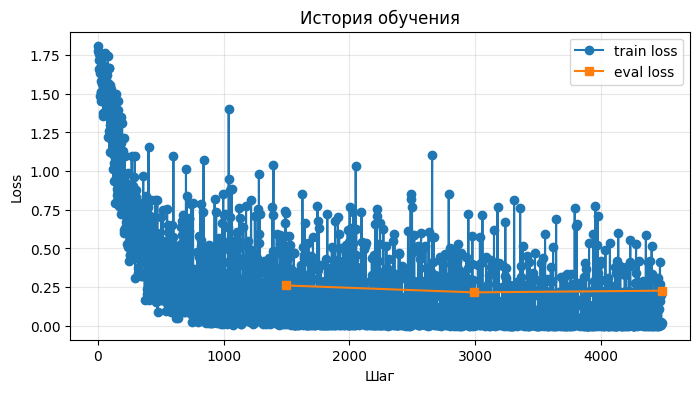

In [17]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(ARTIFACTS_DIR / "training_curves.png")
plt.show()

## Оценка на `validation` и `test` ##
- validation – выборке, которая помогала контролировать обучение;
- test – полностью отложенной выборке.

In [18]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

Validation metrics:
eval_loss: 0.2270
eval_accuracy: 0.9305
eval_f1_macro: 0.8981
eval_f1_weighted: 0.9307
eval_runtime: 28.2650
eval_samples_per_second: 141.0220
eval_steps_per_second: 17.6540
epoch: 3.0000

Test metrics:
eval_loss: 0.2118
eval_accuracy: 0.9365
eval_f1_macro: 0.9058
eval_f1_weighted: 0.9364
eval_runtime: 28.6620
eval_samples_per_second: 139.0690
eval_steps_per_second: 17.4100
epoch: 3.0000


Classification report on test:
              precision    recall  f1-score   support

       anger       0.92      0.94      0.93       540
        fear       0.95      0.86      0.90       473
         joy       0.96      0.95      0.95      1347
        love       0.84      0.86      0.85       325
     sadness       0.96      0.98      0.97      1158
    surprise       0.81      0.85      0.83       143

    accuracy                           0.94      3986
   macro avg       0.91      0.91      0.91      3986
weighted avg       0.94      0.94      0.94      3986



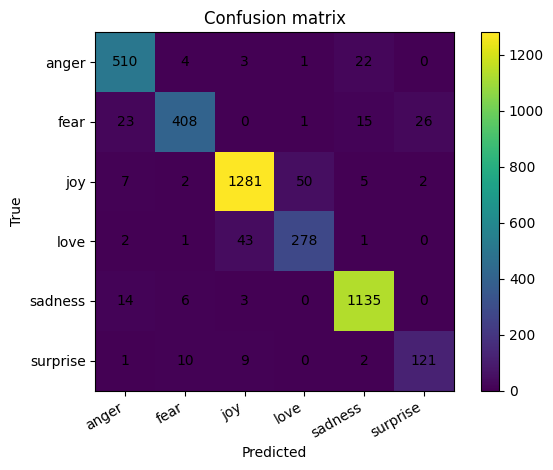

In [22]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots()
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png")
plt.show()



In [23]:
# на матрице ошибок на test-части видно, что модель чаще всего путает классы joy с love (43 ошибки) и love с joy (50 ошибка),
# по сути эмоции удовольствия и любви может быть действительно тяжело объективно определить даже на человеческом уровне.
# тем не менее модель чаще всего верно классифицировала классы joy и sadness, потому что это самые яркие, выразительные и противоположные эмоции, 
# тем самым их легче классифировать.

## Таблица ошибок на тестовой выборке ##

In [24]:
test_texts = test_df.reset_index(drop=True)["text"]
error_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "pred_confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="pred_confidence", ascending=False).reset_index(drop=True))

,text,true_label,pred_label,pred_confidence
0,i did not feel any emotion or was deeply saddened or stunned for that matter,surprise,sadness,0.9996
1,i had climbed on a cherry tree alone and there was a thick caterpillar beside my fingers i feel disgusted by caterpillars and snakes i w...,fear,anger,0.9996
2,i feel i can only hope im not alone in these thoughts and im sure to all you fellow exchange students you probably have the same thought...,sadness,joy,0.9996
3,i feel no joy no pride there is nothing to be admired in that foul achievement,love,joy,0.9995
4,i noticed myself feeling victimized resentful fearful ripped off crazy my body reacted with sensations of tension and chaos,sadness,anger,0.9994
...,...,...,...,...
248,i could feel was love and joy and pride when i looked at those two sweet little faces,love,joy,0.5334
249,i actually stop to think about it it makes me feel quite overwhelmed,fear,surprise,0.5296
250,i am not even sure how to formulate my thoughts since i just put it down and am feeling slightly overwhelmed,fear,surprise,0.5199
251,im feeling so helpless clueless and homesick,fear,sadness,0.5153


In [25]:
# из таблицы видно, что есть ошибки классификации даже, когда модель уверена на 0.999+ (pred_confidence)

## Проверка модели ##
Проведем эксперимент на 100 текстах и запишем результаты в csv файл

In [26]:
def predict_texts(ds) -> pd.DataFrame:
    texts = list(ds["text"])
    true_labels = list(ds["labels"])
    
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
    
    pred_ids = probs.argmax(axis=1)

    rows = []
    for text, true_id, pred_id, prob_vector in zip(texts, true_labels, pred_ids, probs):
        rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "confidence": float(round(prob_vector[pred_id], 4)),
        })

    return pd.DataFrame(rows)

test_subset = test_ds.select(range(100))
sample_df = predict_texts(test_subset)
display(sample_df)
sample_df.to_csv(ARTIFACTS_DIR / "sample_predictions.csv", index=False)
print(f"Results saved to csv file")

,text,true_label,pred_label,confidence
0,i just feel guilty that he died outside my window whilst i slept and did nothing to help him,sadness,sadness,0.9997
1,i feel defeated and low,sadness,sadness,0.9997
2,i am tired of feeling unloved undesired unappreciated and unsupported,sadness,sadness,0.9995
3,i feel it captures the peaceful serenity which is so relaxing and inviting here in pines lake,joy,joy,0.9997
4,i was a bit more bouncier than usual i didnt feel as grouchy about everything as normal,anger,anger,0.9996
...,...,...,...,...
95,i am so sorry you are feeling so sad,sadness,sadness,0.9997
96,i had tuition the next day because i wasnt feeling well n i felt so damned sleepy,joy,joy,0.9996
97,im finally feeling a little more productive,joy,joy,0.9997
98,i feel really irritable when im surrounded with it,anger,anger,0.9996


Results saved to csv file
